### Exercise 5.1

<br>

1) Read the attached file "bank.csv" in the CSV file using pandas. Pay attention to the file delimeter. Inspect the resulting dataframe with respect to the column names and the variable types.

2) Pick data from the following columns to a second dataframe `df2`: `y`, `job`, `marital`, `default`, `housing`, `poutcome`.

3) Convert categorical variables to dummy numerical values using the command

`df3 = pd.get_dummies(df2,columns=['job','marital','default','housing','poutcome'])`

4) Produce a heat map of correlation coefficients for all variables in `df3`. Describe the amount of correlation between the variables in your own words.

5) Select the column called `y` of `df3` as the target variable `y`, and all the remaining columns for the explanatory variables `X`.

6) Split the dataset into training and testing sets with 75/25  ratio.

7) Setup a logistic regression model, train it with training data and predict on testing data.

8) Print the confusion matrix (or use heat map if you want) and accuracy score for the logistic regression model.


### Exercise 5.2

Consider the data from CSV file `weight-height.csv`.

1) Read data into a pandas dataframe.

2) Pick the target variable `y` as weight in kilograms, and the feature variable `X` as height in centimeters.

3) Split the data into training and testing sets with 80/20 ratio.

4) Scale the training and testing data using normalization and standardization.

5) Fit a KNN regression model with `k=5` to the training data without scaling, predict on unscaled testing data and compute the $R^2$ value.



Initial Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB
None

First 5 rows:
   age          job  marital  education default  balanc

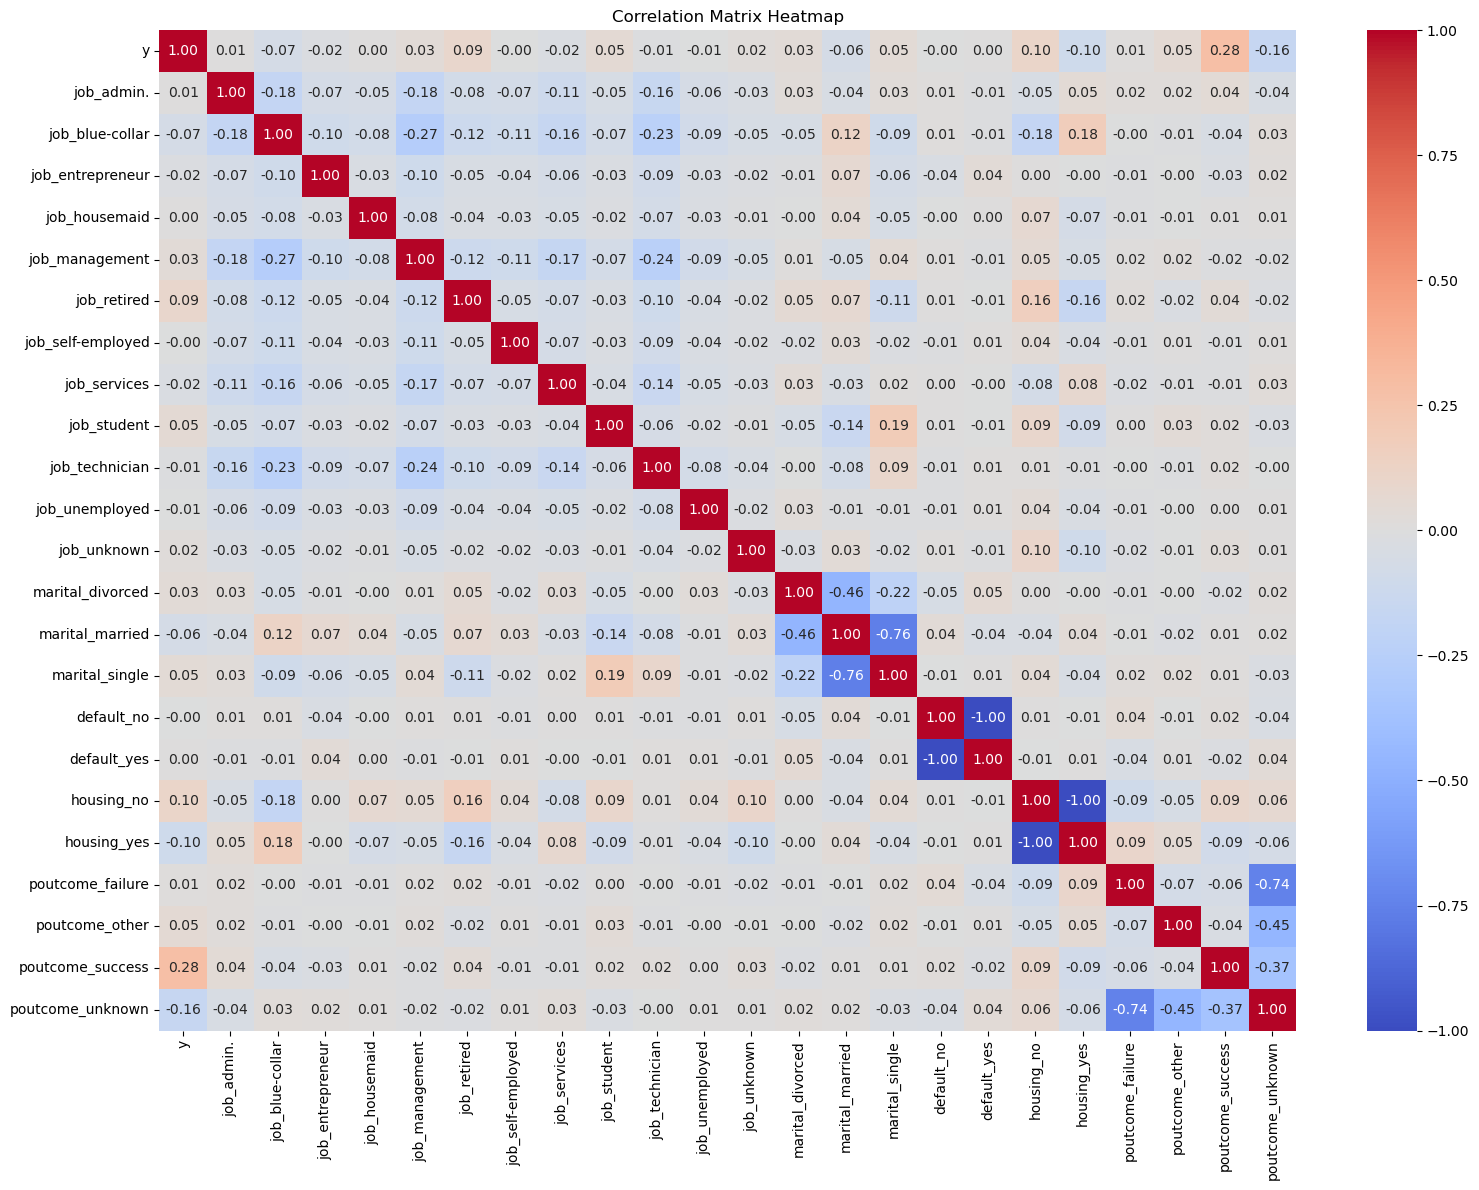


Accuracy Score: 0.8983

Confusion Matrix:
[[997   9]
 [106  19]]


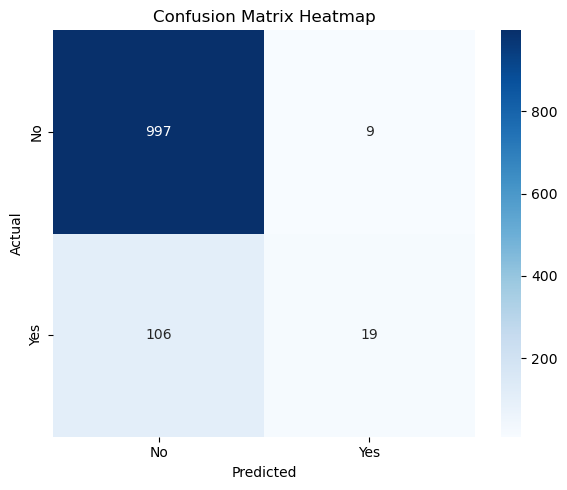

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv('bank (1).csv', delimiter=';')

print("Initial Dataframe Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
df2 = df[['y', 'job', 'marital', 'default', 'housing', 'poutcome']].copy()
df2['y'] = df2['y'].map({'yes': 1, 'no': 0})
df3 = pd.get_dummies(df2, columns=['job', 'marital', 'default', 'housing', 'poutcome'], dtype=int)
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(df3.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True, ax=ax)
ax.set_title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png') 
plt.show()

y = df3['y']
X = df3.drop(columns=['y'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy Score: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=ax)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
df = pd.read_csv('weight-height (2).csv')
df['Height_cm'] = df['Height'] * 2.54
df['Weight_kg'] = df['Weight'] * 0.45359237
X = df[['Height_cm']]
y = df['Weight_kg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
min_max_scaler = MinMaxScaler()
X_train_normalized = min_max_scaler.fit_transform(X_train)
X_test_normalized = min_max_scaler.transform(X_test)
std_scaler = StandardScaler()
X_train_standardized = std_scaler.fit_transform(X_train)
X_test_standardized = std_scaler.transform(X_test)
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R^2 value on unscaled data: {r2:.4f}")

R^2 value on unscaled data: 0.8346
